In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Demo showing how to calculate information content (IC) of audio files

In [3]:
from audio_ic import ICCalcHelper, PERIODE_MUSIC_2_LATENT
import numpy as np
import matplotlib.pyplot as plt

/home/mathias/.conda/envs/audioic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initialize the ICCalcHelper on a device using the provided checkpoint trained on multitrack music

In [4]:
device = 'cuda'
ic_calc_helper = ICCalcHelper(device=device)

Input an audio-file or a numpy array containing a wav at 44100Hz. Choose the audio-type (music or voice)

In [5]:
audio_file = 'Acoustic Grand Piano.wav'
audio_type = 'music'
heading_nan_pad, trailing_nan_padding, len_wo_pad, latents_padded = ic_calc_helper.encode_m2l(audio_file, silence_extractor=audio_type)
nll = ic_calc_helper.ic(heading_nan_pad, trailing_nan_padding, len_wo_pad, latents_padded)
nll = nll[0]


/home/mathias/.conda/envs/audioic/lib/python3.11/site-packages/torch/nn/modules/conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,


Plot resulting IC Curve

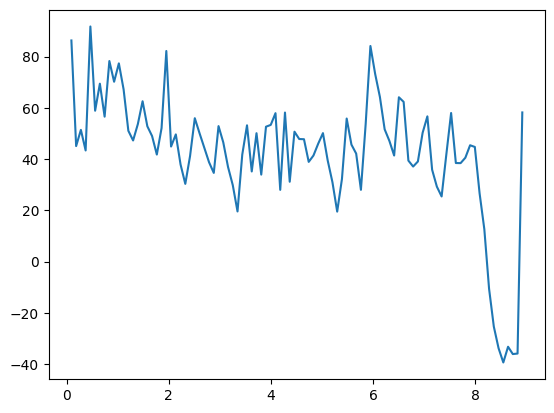

In [6]:

time = (np.arange(len(nll)) + 1) * PERIODE_MUSIC_2_LATENT
plt.plot(time, nll) 